In [2]:
import glob
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots
import seaborn as sns

In [3]:
plt.style.use("science")

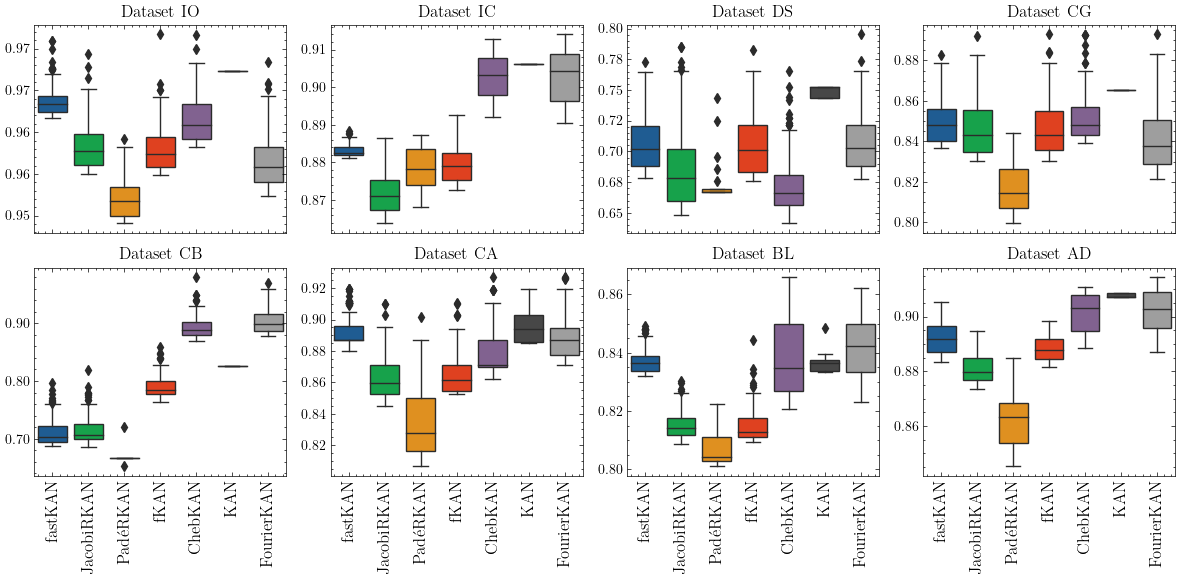

In [4]:
datasets = ["IO", "IC", "DS", "CG", "CB", "CA", "BL", "AD"]
kans = ["fastKAN", "JacobiRKAN", "PadéRKAN","fKAN", "ChebKAN", "KAN", "FourierKAN"]

fig, axs = plt.subplots(2, 4, sharex=True, figsize=(12, 6))
axs = axs.flat
for i, dataset in enumerate(datasets):
    files = glob.glob("results/**/*%s*.csv" % dataset)
    models = {}
    for file in files:
        model = re.search(r"/\w+/", file).group(0)[1:-1]
        if model in ["wavKAN"]:
            continue
        if model == "rKAN":
            model = "PadéRKAN"
        if model == 'JacobiKAN':
            model = "JacobiRKAN"
        models[model] = sorted(pd.read_csv(file).value.values)[-int(len(pd.read_csv(file).value.values) * 0.2):]

    values = ([models[kan] for kan in kans])

    sns.boxplot(values, ax=axs[i])
    # sns.violinplot(values[-10000:],ax=axs[i],cut=0)
    axs[i].set_xticks(range(len(kans)), kans,rotation=90,fontweight=900, fontsize=12)
    axs[i].set_title("Dataset %s" % dataset,fontweight=900, fontsize=12)
    from matplotlib.ticker import FuncFormatter
    def format_func(value, tick_number):
        return f'{value:.2f}'
    
    formatter = FuncFormatter(format_func)
    axs[i].yaxis.set_major_formatter(formatter)
fig.tight_layout()

fig.savefig("scores-boxplot.pdf", bbox_inches="tight")

In [5]:
models[model] = sorted(pd.read_csv(file).value.values)[:]

In [12]:
for i, dataset in enumerate(datasets):
    files = glob.glob("results/**/*%s*.csv" % dataset)
    models = {}
    for file in files:
        model = re.search(r"/\w+/", file).group(0)[1:-1]
        if model in ["wavKAN"]:
            continue
        if model == "rKAN":
            model = "PadéRKAN"
        if model == 'JacobiKAN':
            model = "JacobiRKAN"

        models[model] = pd.read_csv(file).sort_values("value").iloc[-int(len(pd.read_csv(file).value.values) * 0.2):, 2:]

    # plt.figure(figsize=(6,4))
    table = {}
    depth = []
    for model in kans:
        col = "params_depth"
        depth.append(models[model].params_depth.values)
        A = models[model].filter(like="params_neurons_layer_").mean(skipna=True, axis=1)
        
        # print(
        #     "%10s %.1f %.1f %.1f %.1f" % (model, models[model][col].mean(), models[model][col].std(), A.mean(), A.std())
        # )
        table[model] = ([models[model][col].mean(), models[model][col].std(), A.mean(), A.std()])

    for model in ["PadéRKAN"]:
        A = models[model].filter(like="params_orders1_layer_").mean(skipna=True, axis=1)
        B = models[model].filter(like="params_orders2_layer_").mean(skipna=True, axis=1)
        # print("%10s %.1f %.1f" % (model, A.mean(), A.std()))
        table[model].extend([(round(A.mean(),1),round(B.mean(),1)), (round(A.std(),1), round(B.std()))])
    
    for model in ["JacobiRKAN", "fKAN", "ChebKAN"]:
        A = models[model].filter(like="params_orders_layer_").mean(skipna=True, axis=1)
        # print("%10s %.1f %.1f" % (model, A.mean(), A.std()))
        table[model].extend([A.mean(), A.std()])
    
    for model in ['KAN']:
        A = models[model].params_k.values
        # print("%10s %.1f %.1f" % (model, A.mean(), A.std()))
        table[model].extend([A.mean(), A.std()])
    
    for model in ['fastKAN', 'FourierKAN']:
        # print("%10s %.1f %.1f" % (model, A.mean(), A.std()))
        table[model].extend(['-','-'])
    
    for model in ['FourierKAN']:
        A = models[model].filter(like="params_grids_").mean(skipna=True, axis=1)
        # print("%10s %.1f %.1f" % (model, A.mean(), A.std()))
        table[model].extend([A.mean(), A.std()])
    
    for model in ['KAN']:
        A = models[model].params_grid.values
        # print("%10s %.1f %.1f" % (model, A.mean(), A.std()))
        table[model].extend([A.mean(), A.std()])
    
    for model in ['fastKAN', 'fKAN', 'JacobiRKAN', 'ChebKAN', 'PadéRKAN']:
        # print("%10s %.1f %.1f" % (model, A.mean(), A.std()))
        table[model].extend(['-','-'])
    # break
    df = pd.DataFrame(table).T
    df.columns=['Layers', '','Neurons', '', 'Order', '', 'Grid', '']
    # print(dataset)
    print(df.to_latex(float_format="%.1f",caption=dataset))

\begin{table}
\caption{IO}
\begin{tabular}{lllllllll}
\toprule
 & Layers &  & Neurons &  & Order &  & Grid &  \\
\midrule
fastKAN & 1.3 & 0.5 & 144.5 & 39.2 & - & - & - & - \\
JacobiRKAN & 1.5 & 0.8 & 77.0 & 13.0 & 2.2 & 0.4 & - & - \\
PadéRKAN & 2.8 & 1.4 & 124.7 & 30.1 & (5.0, 2.3) & (0.6, 0) & - & - \\
fKAN & 4.9 & 1.1 & 71.1 & 11.1 & 3.9 & 0.6 & - & - \\
ChebKAN & 2.1 & 0.3 & 123.2 & 25.1 & 4.9 & 0.3 & - & - \\
KAN & 1.0 & 0.0 & 40.0 & 0.0 & 1.0 & 0.0 & 7.0 & 0.0 \\
FourierKAN & 2.6 & 0.6 & 37.2 & 6.3 & - & - & 1.9 & 0.6 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{IC}
\begin{tabular}{lllllllll}
\toprule
 & Layers &  & Neurons &  & Order &  & Grid &  \\
\midrule
fastKAN & 2.4 & 0.7 & 156.2 & 20.5 & - & - & - & - \\
JacobiRKAN & 1.9 & 1.5 & 19.0 & 10.0 & 3.7 & 0.6 & - & - \\
PadéRKAN & 4.0 & 1.2 & 98.0 & 39.6 & (4.5, 2.9) & (0.5, 1) & - & - \\
fKAN & 7.6 & 1.8 & 43.3 & 7.9 & 3.9 & 0.4 & - & - \\
ChebKAN & 1.0 & 0.0 & 141.4 & 36.4 & 5.1 & 0.6 & - & - \\
KAN & 2.0 

In [35]:
for k,v in table.items():
    print(k, len(v))

fastKAN 8
JacobiRKAN 8
PadéRKAN 8
fKAN 8
ChebKAN 8
KAN 8
FourierKAN 8
